In [ ]:
from IPython.display import Image, display
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langgraph.graph import StateGraph
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from operator import add as add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from google import genai
from langchain_community.tools import DuckDuckGoSearchRun

In [3]:
load_dotenv() # This now loads your GOOGLE_API_KEY

pdf_path = "Stock_Market_Performance_2024.pdf"
persist_directory = "./chroma_db"
collection_name = "stock_market"

# 1. Using a free, local, open-source embedding model
print("Loading local HuggingFace embeddings...")
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# 2. Database Check & Creation
if os.path.exists(persist_directory):
    print("Vector store already exists. Loading existing database...")
    vectorstore = Chroma(
        persist_directory=persist_directory, 
        embedding_function=embeddings, 
        collection_name=collection_name
    )
else:
    print("Creating new vector store from PDF...")
    if not os.path.exists(pdf_path):
        raise FileNotFoundError(f"PDF file not found: {pdf_path}")
        
    pdf_loader = PyPDFLoader(pdf_path)
    pages = pdf_loader.load()
    
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    pages_split = text_splitter.split_documents(pages)

    os.makedirs(persist_directory, exist_ok=True)
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_directory,
        collection_name=collection_name
    )
    print("Created and saved ChromaDB vector store!")

retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 5})
print("Cell 1 Complete. Ready to build the graph!")

Loading local HuggingFace embeddings...
Vector store already exists. Loading existing database...
Cell 1 Complete. Ready to build the graph!


## A projekt tartalma:
* 1. rész: külső adatforrás beolvasása és vektortérbe beágyazása
* 2. rész: agent felépítése és a tool-jainak az implementálása
* 3. rész: az agent meghívása

A RAG agent chatbot működése röviden:
- a felhasználó elindítja és ad egy utasítást / kérdést a modellnek
- az llm értelmezi ezt, és ez alapján eldönti, hogy ez a kérdés a beágyazott dokumentum tartalmához kapcsolódó lehet-e
- amennyiben igen, akkor meghívja a retriever tool-t, impliciten beágyazza az inputot is a vektoradatbázis vektorterébe, és a hozzá leghasonlóbb 5 db vektort kiválasztja (Retrieve), a saját üzenetéhez hozzáadja (Augmenting), végül generál egy értelmes választ ezzel a kiegészült tudással (Generating)
- ha nem a beágyazott dokumentumhoz kapcsolódik a kérdés, akkor megvizsgálja, hogy ő maga meg tudja-e válaszolni a saját tudása alapján, ha igen, akkor nem használ fel tool-t, és simán csak válaszol a saját tudása szerint
- ha nem tudja megválaszolni (mert mondjuk egy éppen aktuális eseményre kérdez a felhasználó), akkor a web search tool-t veszi használatba, és egy internetes keresés segítségével válaszolja meg a kérdést
- a beszélgetés során emlékszik a beszélgetés korábbi tartalmaira, így azokra alapuló kérdésekre is tud válaszolni

Legjelentősebb bottleneck-ek: megfelelő, tool-ok kezelésére képes LLM használata, például gemini 2.0 flash-lite, ez viszont az ingyenes limitet nagyon hamar túllépi. Próbáltam ezért saját gépemen lokálisan futtatva más LLM-mel is (llama3.1:8b), viszont ez nem volt alkalmas a pontos toolkezelésre, és így az agentic viselkedés bemutatására. Ez utóbbi esetben a lokális hardver képessége is egy bottleneck-nek bizonyult nálam, mert gyenge a laptopom a rendes teszteléshez.

### 1. rész: a (`Stock_Market_Performance_2024.pdf`) beolvasása és vektortérbe ágyazása

A RAG‑rendszer első lépése, hogy a nyers PDF‑ből olyan formátumot hozzon létre, amelyet a modell hatékonyan tud keresni és felhasználni. A PDF‑ek jellemzően hosszú, összefüggő szövegek, ezért a chatbot nem tudna bennük közvetlenül keresni. Ez lesz megoldás erre:

* feldarabolni a dokumentumot kisebb egységekre (chunking),  
* minden darabot beágyazni egy nagy dimenziós vektortérbe,  
* ezeket a vektorokat egy gyorsan kereshető adatbázisban tárolni.

Ez a három lépés biztosítja, hogy a chatbot a későbbiekben releváns szövegrészeket tudjon visszakeresni, és ezek alapján pontosabb válaszokat adjon.

### **Miért érdemes ChromaDB-t használni?**

A Chroma egy lokálisan, könnyen és gyorsan futtatható vektoradatbázis, amely ideális fejlesztéshez és kisebb‑közepes projektekhez. Előnyei:

* **Egyszerű integráció LangChain-nel, LangGraph-fal** – natív támogatás, minimális konfiguráció
* **Helyben fut**, nincs szükség külső szolgáltatásra vagy API‑kulcsra  
* **Gyors HNSW (Hierarchical Navigable Small World) indexelés**, ami hatékony similarity search-t biztosít
* **Perzisztencia** – a vektorok menthetőek, így nem kell minden futásnál újra beágyazni azokat  
* **Költségmentes**, ellentétben például a Pinecone‑nal

### **Bottleneck**

* A Chroma teljesítménye a gép memóriájától és CPU‑jától függ, így nagy dokumentumhalmaznál (több, mint 10.000-nél) a keresés és indexelés lassú lehet már.

### **Miért az *all‑MiniLM‑L6‑v2* embedding modell?**

Ez a modell a Sentence Transformers egyik legjobb „lightweight” embeddingje. A választás indokai:

* **Gyors** – CPU‑n is fut, GPU nélkül is használható
* **Kicsi** – alacsony memóriaigény
* **384 dimenziós embedding** – kisebb vektorméret, gyorsabb keresés, kisebb adatbázis
* **Nyílt forráskódú** – nincs API‑költség

### **Hátrányok**

* Nem olyan erős, mint a nagyobb modellek (pl. `all-mpnet-base-v2` vagy OpenAI text-embedding-3-large).  
* Bonyolult, nagyon technikai dokumentumoknál néha kevésbé pontos szemantikus leképezést ad.  
* A 384 dimenzió kompromisszum: gyors, de nem a legpontosabb.

### **Bottleneck**

* Az embedding számítás CPU‑n történik, nagy dokumentumoknál ez a leglassabb lépés.  
* A modell egyszerre csak korlátozott mennyiségű szöveget tud feldolgozni → batch‑elés szükséges nagyobb adathalmaznál.

### **Mit jelent a chunking, és miért 1000 karakter?**

A chunking a dokumentum logikai darabokra vágása, hogy a modell kezelni tudja őket. A chunk:

* egy szövegrészlet,  
* amelyet külön embedding vektorként tárolsz,  
* és amelyet a retriever külön-külön tud visszaadni.

### **Miért kell chunkolni?**

* A nyelvi modellek nem tudnak több tízezer karaktert egyszerre feldolgozni.  
* A vektoradatbázis kisebb egységeket tud hatékonyan összehasonlítani.  
* A chatbot így csak a releváns részeket kapja vissza, nem az egész dokumentumot.

### **Miért pont 1000 karakter?**

Ez egy bevált kompromisszum:

* Elég hosszú, hogy egy gondolatmenet vagy bekezdés egyben maradjon.  
* Elég rövid, hogy a modell gyorsan embedelje és visszakeresse.  
* Jól működik pénzügyi, technikai és elemző PDF‑eknél, ahol a tartalom strukturált.

A 200 karakteres overlap segít, hogy a darabolás ne vágjon ketté fontos mondatokat vagy táblázatokat.

#### **Hátrányok**

* Ha túl nagy a chunk, a modell „felhígul”, és kevésbé lesz pontos a keresés.  
* Ha túl kicsi, túl sok vektor keletkezik → lassabb keresés, nagyobb tárhely.  
* A PDF‑ek gyakran rosszul strukturáltak → chunking néha „széttöri” a logikát.

#### **Bottleneck**

* A chunkolás CPU‑intenzív, különösen nagy dokumentumoknál.  
* A sok chunk → sok embedding → sok írási művelet a vektoradatbázisba.

skálázhatóság szempontjából nem jó, hogy csak egy pdf-et olvasok be: sokkal jobb lenne, ha vagy egy mappát, vagy bármilyen dokumentumot beolvashatnék

In [ ]:
# Load environment variables from .env, in this case the LLM API keys
load_dotenv()

# Configuration
PDF_PATH = "Stock_Market_Performance_2024.pdf"
PERSIST_DIRECTORY = "./chroma_db"
COLLECTION_NAME = "stock_market"

def initialize_vectorstore(file_path: str, persist_dir: str) -> Chroma:
    """
    Initializes or loads a local ChromaDB vector store from a specific PDF document.
    """
    print("Loading local HuggingFace embeddings...")
    embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

    # Check if database already exists to save time and compute
    if os.path.exists(persist_dir):
        print("Vector store already exists. Loading existing database...")
        return Chroma(
            persist_directory=persist_dir, 
            embedding_function=embeddings, 
            collection_name=COLLECTION_NAME
        )
        
    print(f"Creating new vector store from '{file_path}'...")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"PDF file not found at: {file_path}")
        
    # 1. Load the single PDF
    loader = PyPDFLoader(file_path)
    pages = loader.load()
    print(f"Loaded {len(pages)} pages from the document.")
    
    # 2. Chunk the text
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    pages_split = text_splitter.split_documents(pages)

    # 3. Embed and store
    os.makedirs(persist_dir, exist_ok=True)
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_dir,
        collection_name=COLLECTION_NAME
    )
    print("Created and saved ChromaDB vector store!")
    return vectorstore

# Execute the pipeline
db = initialize_vectorstore(PDF_PATH, PERSIST_DIRECTORY)

if db:
    # Set up the retriever to fetch the top 5 most relevant chunks
    retriever = db.as_retriever(search_type="similarity", search_kwargs={"k": 5})
    print("Cell 1 Complete. Single-document retriever is ready!")

Loading local HuggingFace embeddings...
Vector store already exists. Loading existing database...
✅ Cell 1 Complete. Single-document retriever is ready!


## Phase 2: Adaptive Agentic RAG Graph & Tool Routing

This phase implements the **Adaptive Agentic Architecture**. Instead of a linear script, we use LangGraph to construct a state machine where the LLM acts as the reasoning engine. Based on the user's query, the agent dynamically decides whether to fetch private context, search the public web, or answer directly from its internal knowledge.

### 🏗️ Architecture Decisions
* **Native Tool Calling:** We bind custom Python functions directly to the LLM using `.bind_tools()`. This leverages the model's fine-tuning for function calling, ensuring it outputs the correct JSON structures to trigger tools.
* **Fallback Routing:** By introducing a `web_search_tool` (via DuckDuckGo) alongside the `retriever_tool`, we drastically reduce out-of-domain hallucinations. 
* **Stateful Conversations:** LangGraph's `MemorySaver` checkpointer is injected into the compiled graph, saving the `AgentState` (message history) per session thread to allow for multi-turn follow-up questions.

### ⚠️ Known Bottlenecks & Trade-offs
* **LLM Tool Misalignment (Small Models):** When using smaller local models (e.g., Llama 3.1 8B), the agent may become "trigger happy" and attempt to use tools for casual conversation (like jokes or greetings). To mitigate this, the System Prompt and Tool Docstrings employ heavy *Defensive Prompt Engineering* with explicit negative constraints.
* **Latency Multiplier:** Because this is an agentic loop, a single user question might result in multiple sequential API/inference calls (Think $\rightarrow$ Search $\rightarrow$ Read $\rightarrow$ Answer), inherently increasing response latency compared to a single-pass script.
* **Context Window Bloat:** The `MemorySaver` appends every tool response to the message list. Over a long conversation, this will bloat the context window, slowing down local inference and potentially degrading LLM focus.

### Az elérhető Gemini modellek arra az estre, ha kisebbre kéne váltani, hogy a napi ingyenes limitet ne lépje túl:

In [ ]:

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

print("Available Gemini models:\n" + "-" * 30)

for model in client.models.list():
    print(model.name.split("/")[1])

In [ ]:
# 1. Initialize LLM
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-lite", temperature=0)
# llm = ChatOllama(model="llama3.1:8b", temperature=0)

# 2. Define Tools (With Defensive Docstrings for smaller models)
@tool
def retriever_tool(query: str) -> str:
    """
    CRITICAL: ONLY use this tool if the user explicitly asks about the "Stock Market Performance in 2024".
    DO NOT use this tool for general knowledge, coding, greetings, or jokes.
    """
    print(f"\n📄 [TOOL ACTIVATED] Searching local database for: '{query}'")
    
    # NOTE: 'retriever' is inherited from Cell 1
    docs = retriever.invoke(query) 
    if not docs:
        return "I found no relevant information in the internal documents."
    results = [f"Document {i+1}:\n{doc.page_content}" for i, doc in enumerate(docs)]
    return "\n\n".join(results)

@tool
def web_search_tool(query: str) -> str:
    """
    CRITICAL: ONLY use this tool to search the internet for CURRENT EVENTS, WEATHER, or REAL-TIME NEWS.
    DO NOT use this tool for casual conversation, math, or jokes.
    """
    print(f"\n🌐 [TOOL ACTIVATED] Searching the web for: '{query}'")
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

# Bundle tools and bind to LLM
tools = [retriever_tool, web_search_tool]
llm_with_tools = llm.bind_tools(tools)

# 3. Define Graph State & System Prompt
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

SYSTEM_PROMPT = """You are an intelligent, professional AI assistant. 
You have access to specific tools, but you MUST follow these strict rules:
1. CASUAL CHAT: If the user says hello, asks how you are, or asks for a joke, DO NOT use any tools. Answer directly from your own knowledge.
2. STOCK MARKET 2024: If the user asks about the 2024 stock market, you MUST use the 'retriever_tool'.
3. CURRENT EVENTS: If the user asks about real-time news or weather, you MUST use the 'web_search_tool'.

Always cite your sources! If you used the PDF, say "According to the PDF...". If you used the web, say "Based on a web search...".
"""

# 4. Construct the LangGraph State Machine
def build_agent_graph(llm_model, tool_list, prompt_template: str):
    """Compiles the LangGraph nodes and edges into a conversational agent."""
    
    def call_llm(state: AgentState) -> AgentState:
        messages = [SystemMessage(content=prompt_template)] + list(state['messages'])
        response = llm_model.invoke(messages)
        return {'messages': [response]}

    # Initialize Graph
    graph = StateGraph(AgentState)
    
    # Add Nodes
    graph.add_node("llm", call_llm)
    graph.add_node("tools", ToolNode(tool_list))

    # Add Edges (Routing Logic)
    graph.add_conditional_edges("llm", tools_condition) 
    graph.add_edge("tools", "llm")
    graph.set_entry_point("llm")

    # Add Checkpointer for memory
    memory = MemorySaver()
    
    return graph.compile(checkpointer=memory)

# Build and compile the agent!
rag_agent = build_agent_graph(llm_with_tools, tools, SYSTEM_PROMPT)
print("Cell 2 Complete. Adaptive Agent Graph compiled and ready!")

✅ Cell 2 Complete. Adaptive Agent Graph compiled and ready!


### Az agent szerkezete a következő ábrán látható:
A szaggatott vonalak a feltételes éleket jelentik a gráfban.

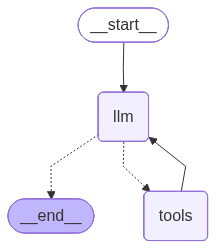

In [7]:
display(Image(rag_agent.get_graph().draw_mermaid_png()))

## Phase 3: Execution Loop & Graceful Error Handling

This final section implements the continuous interaction loop. It connects the user's standard input to the LangGraph agent, manages the conversational memory threading, and implements safeguards against API constraints or local inference timeouts.

### 🏗️ Architecture Decisions
* **Threaded Memory Management:** By passing a `config` dictionary with a specific `thread_id`, we instruct the LangGraph `MemorySaver` to fetch and append to a specific conversational timeline. This allows the bot to resolve pronouns and context seamlessly (e.g., "What was the first one you mentioned?").
* **Graceful Degradation:** Free-tier Cloud APIs (like Gemini) strictly enforce rate limits, and local models (like Ollama) can sometimes time out on heavy queries. We wrap the invocation in a `try/except` block specifically looking for API rate limits (`429 RESOURCE_EXHAUSTED`). Instead of throwing a fatal stack trace and crashing the notebook, the system intercepts the error and instructs the user to wait, preserving the active session.

### ⚠️ Known Bottlenecks & Trade-offs
* **Shared Context (Hardcoded Thread):** Currently, the `thread_id` is hardcoded to `"exhibition_session_1"`. In a live exhibition setting, this means every user inherits the conversation history of the previous user. (Future optimization: Generate a dynamic `uuid.uuid4()` for each new user session, or add a "/clear" command).
* **Synchronous Blocking:** The CLI `input()` function is synchronous and blocks the main execution thread. While perfectly fine for a local Jupyter Notebook demo, migrating this to a web application would require an asynchronous backend (like FastAPI with WebSockets) to handle concurrent users.
* **Manual Retry:** When an error is hit, the system relies on the user to manually wait and re-type their question. An enterprise-grade solution would implement an automatic exponential backoff and retry mechanism behind the scenes.

In [ ]:
from langchain_core.messages import HumanMessage

def running_agent():
    """Starts the interactive CLI chat loop for the Agentic RAG bot."""
    
    print("\n" + "="*55)
    print("ADAPTIVE AGENTIC RAG CHATBOT ONLINE (WITH MEMORY)")
    print("Type 'exit' or 'quit' to end the session.")
    print("="*55)
    
    # Configure the checkpointer thread
    # Note: For a multi-user web app, generate a unique ID per session.
    config = {"configurable": {"thread_id": "exhibition_session_1"}}
    
    while True:
        # 1. Get User Input
        user_input = input("\n You: ")
        
        # Exit condition
        if user_input.strip().lower() in ['exit', 'quit']:
            print("\nShutting down the agent. Goodbye! 👋")
            break
            
        # Skip empty inputs
        if not user_input.strip():
            continue
        
        print("=== USER INPUT ===\n", user_input)

        messages = [HumanMessage(content=user_input)]
        
        try:
            print("\n⏳ Agent Execution Trace:")
            
            # stream_mode="updates" shows us exactly which node is acting
            for event in rag_agent.stream({"messages": messages}, config, stream_mode="updates"):
                for node_name, node_state in event.items():
                    print(f"   🔄 Currently running node: [{node_name}]")
            
            # The final answer is inside the last message of the last node's state
            final_answer = node_state['messages'][-1].content
            print(f"\n=== 🤖 FINAL ANSWER ===\n{final_answer}")
            
        except Exception as e:
            # 3. EXCEPT: If it fails, catch the error gracefully
            error_message = str(e)
            print("\n=== ⚠️ SYSTEM MESSAGE ===")
            
            # Handle API Rate Limiting (Mainly for Cloud LLMs like Gemini)
            if "429" in error_message or "RESOURCE_EXHAUSTED" in error_message:
                print("The model has reached its current processing limit.")
                print("⏳ Please wait about 30 to 60 seconds, then ask your question again!")
            else:
                # Handle unexpected fatal errors (e.g., Ollama crashing)
                print(f"An unexpected error has occurred: {error_message}")
                print("Terminating session to prevent further errors.")
                break

In [11]:
# Start the exhibition bot!
running_agent()


🚀 ADAPTIVE AGENTIC RAG BOT ONLINE (WITH MEMORY)
Type 'exit' or 'quit' to end the session.

⏳ Agent Execution Trace:

=== ⚠️ SYSTEM MESSAGE ===
The model has reached its current processing limit.
⏳ Please wait about 30 to 60 seconds, then ask your question again!

Shutting down the agent. Goodbye! 👋


## Phase 1: Multi-Source Data Ingestion & Vector Store Setup

To simulate an enterprise environment, this ingestion pipeline is designed to be **format-agnostic**. It dynamically routes files to the appropriate LangChain loaders based on their data type, allowing the agent to synthesize knowledge across unstructured (PDFs) and structured (CSVs/Datasets) formats.

### Architecture Decisions & Scalability
* **Dynamic Loader Routing:** Instead of hardcoding a PDF loader, the pipeline scans the `./data` directory and routes files to specific loaders (`PyPDFLoader` for PDFs, `CSVLoader` for tabular data).
* **Local Embeddings:** We use HuggingFace's `all-MiniLM-L6-v2` locally on the CPU, ensuring data privacy and eliminating API embedding costs.
* **Stateful Database:** We persist ChromaDB to the disk (`./chroma_db`) to prevent the compute-heavy process of re-embedding upon every startup.

### Known Bottlenecks & Trade-offs
* **Chunking Structured Data:** Currently, the system uses a standard `RecursiveCharacterTextSplitter`. While great for PDFs, blindly splitting tabular data (like Kaggle CSVs) by character count can sever the relationship between column headers and values. (Future optimization: Implement format-specific chunking strategies before combining the documents).
* **Embedding Model Limits:** The lightweight `all-MiniLM-L6-v2` model is incredibly fast but has a smaller context window and dimensional size, which may struggle to capture deep semantic nuances in highly technical datasets compared to larger, paid models.

In [ ]:
import os
import glob
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader, CSVLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

# Load environment variables
load_dotenv()

# Configuration
DATA_DIRECTORY = "./data"
PERSIST_DIRECTORY = "./chroma_db"
COLLECTION_NAME = "multi_source_knowledge"

def load_documents_dynamically(data_dir: str):
    """Scans the directory and uses the correct loader based on file extension."""

    documents = []

    # Check for PDFs
    for file_path in glob.glob(os.path.join(data_dir, "*.pdf")):
        print(f"Loading PDF: {file_path}")
        loader = PyPDFLoader(file_path)
        documents.extend(loader.load())

    # Check for CSVs (e.g., Kaggle datasets)
    for file_path in glob.glob(os.path.join(data_dir, "*.csv")):
        print(f"Loading CSV: {file_path}")
        loader = CSVLoader(file_path)
        documents.extend(loader.load())

    # You could easily add JSON, TXT, or Markdown loaders here!
    return documents

def initialize_vectorstore(data_dir: str, persist_dir: str) -> Chroma:
    """Initializes or loads a local ChromaDB vector store."""

    print("Loading local HuggingFace embeddings...")
    embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

    if os.path.exists(persist_dir):
        print("Vector store already exists. Loading existing database...")
        return Chroma(
            persist_directory=persist_dir,
            embedding_function=embeddings,
            collection_name=COLLECTION_NAME
        )

    print(f"Creating new vector store from documents in '{data_dir}'...")
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
        print(f"Created '{data_dir}' directory. Please add PDFs or CSVs and run again.")
        return None

    # 1. Dynamically load diverse file types
    pages = load_documents_dynamically(data_dir)

    if not pages:
        print("No readable documents found in the data directory!")
        return None

    print(f"Loaded {len(pages)} chunks across all multi-source documents.")

    # 2. Chunk the text
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    pages_split = text_splitter.split_documents(pages)

    # 3. Embed and store
    os.makedirs(persist_dir, exist_ok=True)
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_dir,
        collection_name=COLLECTION_NAME
    )
    print("Created and saved ChromaDB vector store!")
    return vectorstore

# Execute the pipeline
db = initialize_vectorstore(DATA_DIRECTORY, PERSIST_DIRECTORY)

if db:
    retriever = db.as_retriever(search_type="similarity", search_kwargs={"k": 5})
    print("✅ Cell 1 Complete. Multi-source retriever is ready!")

## Phase 1: Data Ingestion & Vector Store Setup

Before our agent can answer questions, it needs a knowledge base. This section handles the **Standard RAG Pipeline**: loading documents, breaking them into digestible chunks, converting them into mathematical vectors (embeddings), and storing them in a local database.

### 🏗️ Architecture Decisions & Scalability
* **Directory Loading:** Instead of hardcoding a single PDF, we use `PyPDFDirectoryLoader` pointing to a `./data` folder. This makes the system instantly scalable—just drop new reports into the folder, and the system will ingest them automatically.
* **Local Embeddings:** We use HuggingFace's `all-MiniLM-L6-v2`. It runs locally on the CPU, ensuring privacy and eliminating API embedding costs.
* **Stateful Database:** We persist ChromaDB to the disk (`./chroma_db`). This prevents the costly and time-consuming process of re-embedding the documents every time the notebook is restarted.

### ⚠️ Known Bottlenecks & Trade-offs
* **Embedding Model Limits:** While `all-MiniLM-L6-v2` is lightning-fast and free, its smaller dimensional size means it might struggle with highly complex, nuanced semantic connections compared to massive commercial models like OpenAI's `text-embedding-3-large`.
* **Naive Chunking:** We are using `RecursiveCharacterTextSplitter` with a fixed chunk size. A bottleneck here is that a hard character cutoff might split a crucial paragraph or table in half, causing the agent to lose context. (Future optimization: Semantic or structural chunking).
* **Vector Database Scale:** ChromaDB is perfect for exhibition and prototype scales. However, for a massive enterprise dataset (millions of documents), a cloud-native vector database like Pinecone or Weaviate would be required to maintain low-latency retrieval.

In [1]:
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFDirectoryLoader # Upgraded for scalability!
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

# Load environment variables (Google API Key)
load_dotenv()

# Configuration
DATA_DIRECTORY = "./data" # Create this folder and put your PDF(s) here!
PERSIST_DIRECTORY = "./chroma_db"
COLLECTION_NAME = "stock_market"

def initialize_vectorstore(data_dir: str, persist_dir: str) -> Chroma:
    """
    Initializes or loads a local ChromaDB vector store from a directory of PDFs.
    """
    print("Loading local HuggingFace embeddings...")
    embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

    # Check if database already exists to save time and compute
    if os.path.exists(persist_dir):
        print("Vector store already exists. Loading existing database...")
        return Chroma(
            persist_directory=persist_dir,
            embedding_function=embeddings,
            collection_name=COLLECTION_NAME
        )

    print(f"Creating new vector store from documents in '{data_dir}'...")
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
        print(f"Created '{data_dir}' directory. Please add PDFs and run again.")
        return None

    # 1. Load all PDFs from the directory (Scalability upgrade)
    loader = PyPDFDirectoryLoader(data_dir)
    pages = loader.load()

    if not pages:
        print("No PDFs found in the data directory!")
        return None

    print(f"Loaded {len(pages)} pages across all documents.")

    # 2. Chunk the text
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    pages_split = text_splitter.split_documents(pages)

    # 3. Embed and store
    os.makedirs(persist_dir, exist_ok=True)
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_dir,
        collection_name=COLLECTION_NAME
    )
    print("Created and saved ChromaDB vector store!")
    return vectorstore

# Execute the pipeline
db = initialize_vectorstore(DATA_DIRECTORY, PERSIST_DIRECTORY)

if db:
    # Set up the retriever to fetch the top 5 most relevant chunks
    retriever = db.as_retriever(search_type="similarity", search_kwargs={"k": 5})
    print("✅ Cell 1 Complete. Retriever is ready!")

Loading local HuggingFace embeddings...
Vector store already exists. Loading existing database...
✅ Cell 1 Complete. Retriever is ready!


## Phase 2: Adaptive Agentic RAG Graph & Tool Routing

Unlike a standard linear RAG pipeline, this phase implements an **Adaptive Agentic Architecture**. We use LangGraph to construct a state machine where the LLM acts as the reasoning engine. Based on the user's query, the agent dynamically decides whether to fetch private context from the Vector Store, search the public web for real-time data, or answer directly from conversational memory.

### 🏗️ Architecture Decisions
* **Native Tool Calling:** We bind our custom tools directly to the Gemini model (`llm.bind_tools()`). This leverages the model's underlying fine-tuning for function calling, ensuring reliable JSON-formatted tool triggers.
* **Fallback Routing:** By introducing a `web_search_tool` (via DuckDuckGo) alongside our `retriever_tool`, we drastically reduce out-of-domain hallucinations. If the PDF lacks the answer, the agent falls back to the internet.
* **Stateful Conversations:** LangGraph's `MemorySaver` checkpointer is injected into the compiled graph. This saves the `AgentState` (message history) per session thread, allowing for natural, multi-turn follow-up questions.

### ⚠️ Known Bottlenecks & Trade-offs
* **Latency Multiplier:** Because this is an agentic loop, a single user question might result in multiple API calls (e.g., LLM decides to search -> tool executes -> LLM synthesizes answer). This inherently increases response latency compared to a single-pass script.
* **Context Window Bloat:** The `MemorySaver` appends every question, tool response, and answer to the message list. Over a very long conversation, this will eventually bloat the context window, increasing costs and potentially degrading LLM focus. (Future optimization: Implement a rolling window or conversation summarizer node).
* **Web Search Noise:** DuckDuckGo is a free, unauthenticated search tool. While great for prototypes, it can sometimes return noisy, SEO-stuffed snippets or hit IP rate limits during heavy usage. Enterprise versions would benefit from a dedicated API like Tavily or Google Search.

In [2]:
from typing import TypedDict, Annotated, Sequence
from operator import add as add_messages
from langchain_core.messages import BaseMessage, SystemMessage
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# 1. Initialize LLM
# Using the lite model to comfortably handle the 1,000 requests/day free tier limit

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)
#llm = ChatOllama(model="llama3.1:8b", temperature=0)

# 2. Define Tools
@tool
def retriever_tool(query: str) -> str:
    """Searches and returns information from the internal knowledge base (Vector Store)."""
    print(f"\n📄 [TOOL ACTIVATED] Searching local database for: '{query}'")

    # NOTE: 'retriever' must be initialized in Cell 1
    docs = retriever.invoke(query)
    if not docs:
        return "I found no relevant information in the internal documents."
    results = [f"Document {i+1}:\n{doc.page_content}" for i, doc in enumerate(docs)]
    return "\n\n".join(results)

@tool
def web_search_tool(query: str) -> str:
    """Use this tool to search the web ONLY IF the answer cannot be found in the local database."""
    print(f"\n🌐 [TOOL ACTIVATED] Searching the web for: '{query}'")
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

# Bundle tools and bind to LLM
tools = [retriever_tool, web_search_tool]
llm_with_tools = llm.bind_tools(tools)

# 3. Define Graph State & System Prompt
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

SYSTEM_PROMPT = """You are an intelligent AI assistant. You have two tools at your disposal:
1. 'retriever_tool': Always use this FIRST if the user asks about the specific documents in your knowledge base.
2. 'web_search_tool': Use this to search the internet if the user asks about current events, or if the retriever_tool doesn't contain the answer.

Always cite your sources! If you used the internal database, say "According to the document...". If you used the web, say "Based on a web search...".
"""

# 4. Construct the LangGraph State Machine
def build_agent_graph(llm_model, tool_list, prompt_template: str):
    """Compiles the LangGraph nodes and edges into a conversational agent."""

    def call_llm(state: AgentState) -> AgentState:
        messages = [SystemMessage(content=prompt_template)] + list(state['messages'])
        response = llm_model.invoke(messages)
        return {'messages': [response]}

    # Initialize Graph
    graph = StateGraph(AgentState)

    # Add Nodes
    graph.add_node("llm", call_llm)
    graph.add_node("tools", ToolNode(tool_list))

    # Add Edges (Routing Logic)
    graph.add_conditional_edges("llm", tools_condition)
    graph.add_edge("tools", "llm")
    graph.set_entry_point("llm")

    # Add Checkpointer for memory
    memory = MemorySaver()

    return graph.compile(checkpointer=memory)

# Build and compile the agent!
rag_agent = build_agent_graph(llm_with_tools, tools, SYSTEM_PROMPT)
print("✅ Cell 2 Complete. Adaptive Agent Graph compiled and ready!")

✅ Cell 2 Complete. Adaptive Agent Graph compiled and ready!


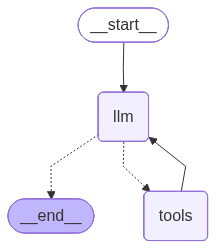

In [4]:
display(Image(rag_agent.get_graph().draw_mermaid_png()))


## Phase 3: Execution Loop & Graceful Error Handling

This final section implements the continuous interaction loop. It connects the user's standard input to the LangGraph agent, manages the conversational memory threading, and implements safeguards against API constraints.

### 🏗️ Architecture Decisions
* **Threaded Memory Management:** By passing a `config` dictionary with a specific `thread_id`, we instruct the LangGraph `MemorySaver` to fetch and append to a specific conversational timeline. This allows the bot to resolve pronouns and context (e.g., "What was the first one you mentioned?").
* **Graceful Degradation:** Free-tier LLM APIs strictly enforce rate limits (Tokens Per Minute / Requests Per Minute). We wrap the invocation in a `try/except` block specifically looking for `429 RESOURCE_EXHAUSTED` errors. Instead of throwing a fatal stack trace and crashing the notebook, the system intercepts the error and instructs the user to wait, preserving the active session and memory.

### ⚠️ Known Bottlenecks & Trade-offs
* **Shared Context (Hardcoded Thread):** Currently, the `thread_id` is hardcoded to `"exhibition_session_1"`. In a live exhibition setting, this means User B will inherit the conversation history of User A. (Future optimization: Generate a dynamic UUID for each new user session or add a "clear memory" command).
* **Synchronous Blocking:** The `input()` function is synchronous and blocks the main execution thread. While perfectly fine for a local Jupyter Notebook demo, migrating this to a web application would require an asynchronous backend (like FastAPI with WebSockets) to handle concurrent users.
* **Manual Retry:** When the rate limit is hit, the system relies on the user to manually wait and re-type their question. An enterprise-grade solution would implement an automatic exponential backoff and retry mechanism (e.g., using the `tenacity` Python library) behind the scenes.

In [3]:
from langchain_core.messages import HumanMessage
import uuid

def running_agent():
    """Starts the interactive CLI chat loop for the Adaptive Agentic RAG bot."""

    print("\n" + "="*50)
    print("🚀 ADAPTIVE AGENTIC RAG BOT ONLINE (WITH MEMORY)")
    print("Type 'exit' or 'quit' to end the session.")
    print("="*50)

    # Configure the checkpointer thread
    # Note: For a multi-user web app, you would generate a unique uuid.uuid4() per session.
    config = {"configurable": {"thread_id": "exhibition_session_1"}}

    while True:
        try:
            # Get user input
            user_input = input("\n👤 You (What is your question?): ")

            # Exit condition
            if user_input.strip().lower() in ['exit', 'quit']:
                print("\nShutting down the agent. Goodbye! 👋")
                break

            # Skip empty inputs
            if not user_input.strip():
                continue

            print(f"\n=== USER INPUT ===\n{user_input}")

            # Format the input for LangGraph
            messages = [HumanMessage(content=user_input)]

            # Execute the agentic loop
            result = rag_agent.invoke({"messages": messages}, config)

            # Extract and print the final generated response
            final_answer = result['messages'][-1].content
            print(f"\n=== 🤖 ANSWER ===\n{final_answer}")

        except Exception as e:
            error_message = str(e)
            print("\n=== ⚠️ SYSTEM MESSAGE ===")

            # Handle API Rate Limiting Gracefully
            if "429" in error_message or "RESOURCE_EXHAUSTED" in error_message:
                print("The model has reached its current processing limit.")
                print("⏳ Please wait about 30 to 60 seconds, then ask your question again!")
            else:
                # Handle unexpected fatal errors
                print(f"An unexpected error has occurred: {error_message}")
                print("Terminating session to prevent further errors.")
                break

In [ ]:
# Start the exhibition bot!
running_agent()


🚀 ADAPTIVE AGENTIC RAG BOT ONLINE (WITH MEMORY)
Type 'exit' or 'quit' to end the session.

=== USER INPUT ===
how was smp500 performing in 2024?

🌐 [TOOL ACTIVATED] Searching the web for: 'S&P 500 performance in 2024'


Impersonate 'chrome_119' does not exist, using 'random'


## Megnézem, hogy milyen modellek érhetőek el:

In [ ]:

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

print("Available Gemini models:\n" + "-" * 30)

for model in client.models.list():
    print(model.name.split("/")[1])

In [ ]:
# Initialize the Gemini model (using the 1,000 requests/day lite model!)
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)
from langchain_ollama import ChatOllama
#llm = ChatOllama(model="llama3.1:8b", temperature=0)


# Tool 1: The PDF Retriever
@tool
def retriever_tool(query: str) -> str:
    """Searches and returns information from the Stock Market Performance 2024 PDF document."""
    print(f"\n📄 [TOOL ACTIVATED] Searching PDF for: '{query}'")
    docs = retriever.invoke(query)
    if not docs:
        return "I found no relevant information in the document."
    results = [f"Document {i+1}:\n{doc.page_content}" for i, doc in enumerate(docs)]
    return "\n\n".join(results)

# Tool 2: The Web Search Fallback
@tool
def web_search_tool(query: str) -> str:
    """Use this tool to search the web ONLY IF the answer cannot be found in the PDF or your own knowledge."""
    print(f"\n🌐 [TOOL ACTIVATED] Searching the web for: '{query}'")
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

# Bundle both tools together
tools = [retriever_tool, web_search_tool]
llm = llm.bind_tools(tools)

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# 2. UPDATED PROMPT: Giving the AI strict instructions on how to use its new tools
system_prompt = """You are an intelligent AI assistant. You have two tools at your disposal:
1. 'retriever_tool': Always use this FIRST if the user asks about the Stock Market Performance in 2024.
2. 'web_search_tool': Use this to search the internet if the user asks about current events, or if the retriever_tool doesn't contain the answer.

Always cite your sources! If you used the PDF, say "According to the PDF...". If you used the web, say "Based on a web search...".
"""

def call_llm(state: AgentState) -> AgentState:
    messages = [SystemMessage(content=system_prompt)] + list(state['messages'])
    message = llm.invoke(messages)
    return {'messages': [message]}

graph = StateGraph(AgentState)
graph.add_node("llm", call_llm)
graph.add_node("tools", ToolNode(tools))

graph.add_conditional_edges("llm", tools_condition) 
graph.add_edge("tools", "llm")
graph.set_entry_point("llm")

memory = MemorySaver()
rag_agent = graph.compile(checkpointer=memory)

mutassam be itt a workflow-t az ábra segítségével:

In [ ]:
display(Image(rag_agent.get_graph().draw_mermaid_png()))

In [5]:
# 4. Run the Chat (Updated with Error Handling)
def running_agent():
    print("\n=== FREE AGENTIC RAG BOT (WITH MEMORY) ===")
    
    # Create a configuration dictionary with a thread_id
    config = {"configurable": {"thread_id": "exhibition_session_1"}}
    
    while True:
        user_input = input("\nWhat is your question (type 'exit' to quit): ")
        if user_input.lower() in ['exit', 'quit']:
            break
        print("\n=== USER INPUT ===")
        print(user_input)

        messages = [HumanMessage(content=user_input)]
        
        try:
            # 1. TRY: Attempt to run the agentic loop
            result = rag_agent.invoke({"messages": messages}, config)
            
            print("\n=== ANSWER ===")
            print(result['messages'][-1].content)
            
        except Exception as e:
            # 2. EXCEPT: If it fails, catch the error and check what went wrong
            error_message = str(e)
            
            print("\n=== SYSTEM MESSAGE ===")
            if "429" in error_message or "RESOURCE_EXHAUSTED" in error_message:
                print("The model has reached its running limit, please wait about 30 to 60 seconds, then ask your question again!")
            else:
                # Catches any other random errors so the bot still doesn't crash
                print(f"The following error has occured: {error_message}")
                break

In [6]:
running_agent()


=== FREE AGENTIC RAG BOT (WITH MEMORY) ===

=== USER INPUT ===
can I ask from you?

📄 [TOOL ACTIVATED] Searching PDF for: 'can I ask from you?'

=== ANSWER ===
Based on the documents provided, it seems that you are asking about the performance of various companies in the stock market in 2024.

According to Document 1 and Document 4, Amazon's (AMZN) stock price rose by approximately 48% in 2024, from around $152 at the end of 2023 to around $219 by December 2024. This added a significant amount to its market capitalization, bringing it back into the vicinity of $1.7-$1.8 trillion.

Document 2 and Document 5 mention that Meta Platforms (Facebook) (META) saw its stock price surge about 72% during the year, making it one of the best-performing large-cap stocks. The share price rose from roughly $352 at the end of 2023 to around $585 by December 2024.

Document 3 and Document 5 also mention that Alphabet Inc., the parent of Google (GOOGL), delivered strong results for shareholders in 2024,